In [ ]:
# Import PyRadtran components
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 24

# stationary simulation at constant altitude, latitude, and longitude but with varying time
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', [10]),
    }
)

# Run a spectral simulation for a single point
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete!")


Simulation complete!


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_2530710/1890333130.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


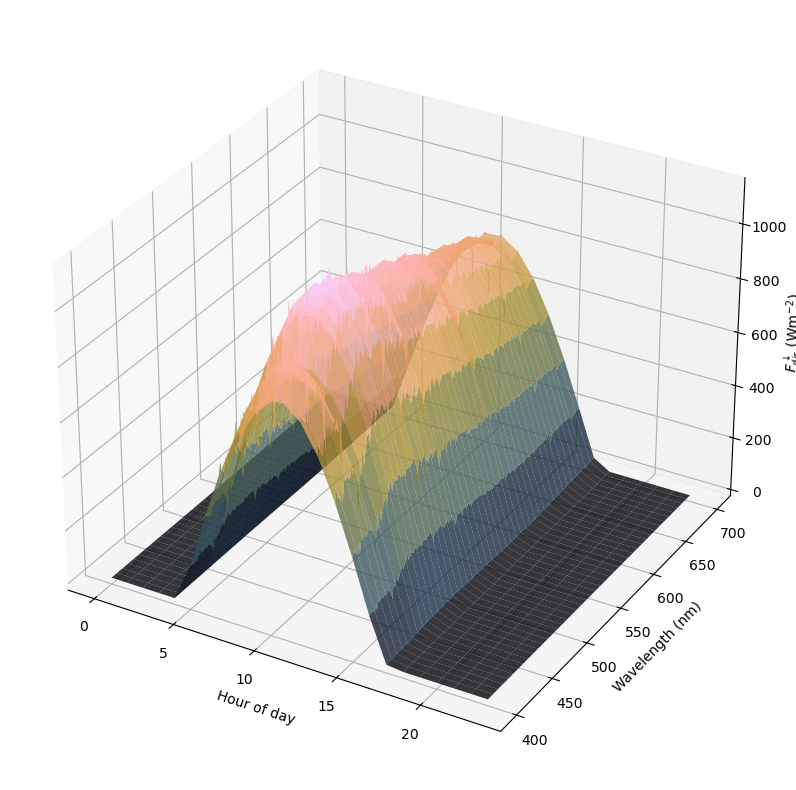

In [2]:
# Plot the results
from cmcrameri import cm

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.batlowK(np.linspace(0, 1, len(ds_sim['wavelength'].values))),
)

x = np.arange(len(ds_sim['time'].values))
y = ds_sim['wavelength'].values
z = ds_sim['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.batlowK, edgecolor='none', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')

plt.tight_layout()
